# DQN with ALE/MsPacman-v5

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `ALE/MsPacman-v5` using the Gymnasium ALE API.

Ms. Pac-Man is a pixel-based Atari env: the observation is a `(210, 160, 3)` RGB frame and the action space is `Discrete(9)`. We apply the same Mnih et al. (2015) preprocessing pipeline as `dqn_enduro` — grayscale, 84×84, 4-frame skip, 4-frame stack — giving a `(4, 84, 84)` uint8 input to the same Nature DQN CNN.

The one meaningful difference from Enduro is `terminal_on_life_loss=True`: Ms. Pac-Man has 3 lives and treating each ghost-death as a terminal signal is standard practice (Mnih et al. 2015 Appendix) — it gives the agent a clear negative signal for dying rather than letting it coast through lost lives mid-episode.

## Imports

In [11]:
import sys, pathlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import ale_py
import gymnasium as gym
gym.register_envs(ale_py)

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Config-driven wiring: change config.yaml and it flows through these builders
# without editing the notebook. Hankel analysis is driven by analysis.hankel_sweep
# in config.yaml (dispatched inside the training loop), so no Hankel import here.
from experiment import load_config, build_env, build_agent, train, make_run_logger
from analysis.registry import resolve_methods
from analysis.low_rank.rank import row_rank_property_check
from analysis.visualisations.heatmaps import plot_matrix_heatmap

## Reading the config file

In [12]:
cfg = load_config("config.yaml")   # loads yaml, resolves device, seeds torch/numpy
print("device:", cfg["experiment"]["_device"])
cfg

device: cuda


{'experiment': {'name': 'dqn_pacman',
  'seed': 52,
  'device': 'cuda',
  'save_artifacts': True,
  '_device': 'cuda'},
 'environment': {'name': 'ALE/MsPacman-v5',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {}, 'state': {}},
  'clip': {'action': False, 'state': {}},
  'atari': {'noop_max': 30,
   'frame_skip': 4,
   'screen_size': 84,
   'terminal_on_life_loss': True,
   'grayscale_obs': True,
   'grayscale_newaxis': False,
   'scale_obs': False,
   'frame_stack': 4}},
 'network': {'fc_hidden': 512},
 'agent': {'replay_buffer_capacity': 500000,
  'batch_size': 128,
  'nn_learning_rate': 0.0001,
  'eps_start': 1.0,
  'eps_min': 0.01,
  'decay_rate': 0.999912,
  'discount_factor': 0.99,
  'TD_LR': 0.005,
  'buffer_util': 4,
  'gd_steps_ceil': 40,
  'grad_clip_norm': 10.0,
  'double': True},
 'training': {'no_episodes': 15000,
  'target_network_update_steps': 100,
  'train_frequency_steps': 100,
  'use_episode_training': False,
  'solved_reward': 2000,
  '

## Creating the Environment

The `atari` block triggers the Atari branch of `make_environment`, wiring `AtariPreprocessing` followed by `FrameStackObservation`. Resulting `observation_space` is `Box(0, 255, (4, 84, 84), uint8)`.

In [13]:
env = build_env(cfg)
obs_shape = env.observation_space.shape   # (4, 84, 84)
n_actions = env.action_space.n
print("obs_shape:", obs_shape, "dtype:", env.observation_space.dtype, "n_actions:", n_actions)

obs_shape: (4, 84, 84) dtype: uint8 n_actions: 9


## CNN Q-network

Same Nature DQN architecture as `dqn_enduro` — no changes needed. The network is game-agnostic: `n_actions` is read from the env at runtime.

| Layer | Spec | Output |
|---|---|---|
| Conv1 | 4 → 32, kernel 8, stride 4 | 32×20×20 |
| Conv2 | 32 → 64, kernel 4, stride 2 | 64×9×9 |
| Conv3 | 64 → 64, kernel 3, stride 1 | 64×7×7 |
| FC1   | 3136 → 512 | 512 |
| FC2   | 512 → n_actions | Q-values |

In [14]:
class NatureCNN(nn.Module):
    """Maps a (C, 84, 84) frame stack to Q-values of shape (n_actions,)."""
    def __init__(self, in_channels, n_actions, fc_hidden=512):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),          nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),          nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 84, 84)
            flat_dim = self.features(dummy).shape[1]
        self.head = nn.Sequential(
            nn.Linear(flat_dim, fc_hidden), nn.ReLU(),
            nn.Linear(fc_hidden, n_actions),
        )

    def forward(self, x):
        x = x.float() / 255.0
        return self.head(self.features(x))

## Creating the Agent

In [15]:
# The net class + its derived dims are genuine code (not config keys), so they
# stay explicit; every agent hyperparameter comes from cfg["agent"] via build_agent.
nn_extra_kwargs = {
    "in_channels": obs_shape[0],
    "n_actions": n_actions,
    "fc_hidden": cfg["network"]["fc_hidden"],
}
agent = build_agent(cfg, env, NatureCNN, nn_extra_kwargs)

## Analysis (Low Rank)

Hankel analysis is driven by the `analysis.hankel_sweep` block in [config.yaml](config.yaml) and dispatched inside the training loop every `ep_freq` episodes — `q_matrix_dqn` discretises each observation dimension into bins, which is meaningless for `(4, 84, 84)` pixel stacks, so no generic per-matrix methods are configured here. Pac-Man ships the single-rollout, whole-episode setting (`n_rollouts: 1`, `sub_trajectory.enabled: false`) — the old behaviour, now on the unified path. Raise `n_rollouts` / flip `sub_trajectory.enabled` to opt into the richer multi-rollout + growing sub-trajectory sweep (see `dqn_seaquest`).

**Run artifacts.** A `RunLogger` snapshots everything under `runs/<timestamp>/` (gitignored): a frozen copy of the config, `rewards.csv`, `hankel_sweep.csv` (per-rollout / per-sub_len rank metrics), `trajectories/` (raw Q/V sequences when `save_trajectories` is set), spectrum figures as `figures/epNNNNNN_*.png` **instead of inline** (keeps this notebook small), and checkpoints in `checkpoints/`: `latest.pt` at every analysis tick, `best.pt` on a new reward-window high, `final.pt` on completion. Restore any of them with `agent.load(path)`. Toggle via `experiment.save_artifacts` in [config.yaml](config.yaml).

In [16]:
# All artifacts from this run (figures, CSV logs, checkpoints) land under
# runs/<timestamp>/ when experiment.save_artifacts is set; otherwise logger is
# None and analysis renders inline. Hankel runs via the analysis.hankel_sweep
# config block (dispatched inside the training loop) — no per-method wiring here.
logger = make_run_logger(cfg)
if logger:
    print("run artifacts ->", logger.dir)

run artifacts -> /home/souparna/Low-Rank-RL-TL/experiments/dqn_pacman/runs/20260707-184601


## Agent Training

Ms. Pac-Man episodes are shorter than Enduro on average (3 lives, quicker deaths early on), but the maze structure means the agent needs many episodes to explore effectively. Expect reward to climb slowly past the random baseline (~200) before showing consistent improvement.

In [17]:
rewards = train(cfg, agent, env, run_logger=logger)

  0%|          | 0/15000 [00:00<?, ?it/s]

episode 0 avg_rewarg: 90.0


  0%|          | 13/15000 [00:05<41:54,  5.96it/s]  

episode 10 avg_rewarg: 103.0


  0%|          | 21/15000 [00:06<26:01,  9.60it/s]

...

episode 2610 avg_rewarg: 734.0


 17%|█▋        | 2621/15000 [52:58<4:52:43,  1.42s/it]

episode 2620 avg_rewarg: 701.0


 17%|█▋        | 2621/15000 [52:59<4:10:17,  1.21s/it]


KeyboardInterrupt: 

## Training and Analysis Plots

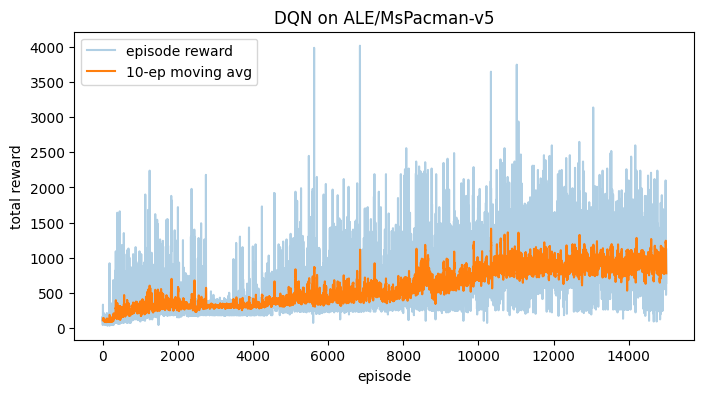

In [ ]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on ALE/MsPacman-v5")
plt.legend()
if logger:
    plt.savefig(logger.dir / "reward_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Q visited-states


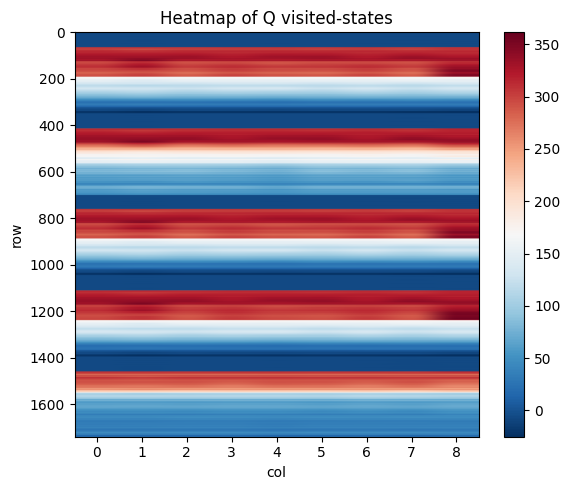

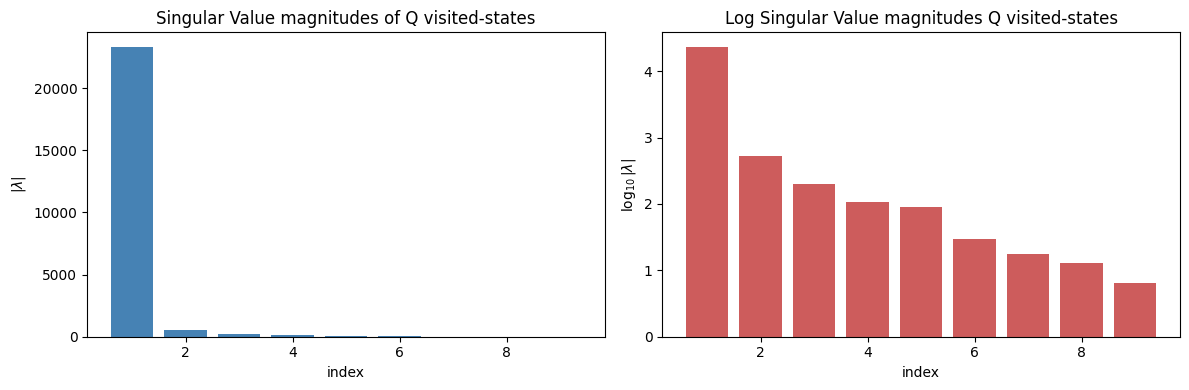

eff_rank: 1, stable_rank: 1.00, spikiness: 1.94, shape: (1740, 9), non-zero rows :1736, non-zero cols:9
top-r leverage spread: row min=5.323e-15 max=0.001939 (uniform 0.0005747) | col min=0.1086 max=0.1192 (uniform 0.1111)
coherence score: row=3.374 col=1.073


In [ ]:
# Post-training: run any generic per-matrix methods + post_methods on the final
# policy (none configured for pixel Pac-Man). Hankel already ran every ep_freq
# during training via hankel_sweep (see hankel_sweep.csv / figures/).
methods = resolve_methods(cfg["analysis"].get("methods", []) + cfg["analysis"].get("post_methods", []))
for method, names in methods:
    results = method(agent=agent, env=env)
    if not isinstance(results, tuple):
        results = (results,)
    for matrix, name in zip(results, names):
        print(name)
        plot_matrix_heatmap(matrix, name, save_to=logger.figure_path(f"{name} heatmap") if logger else None)
        r, sr, spk, shape, irs, ics, rc, cc, nzr, nzc = row_rank_property_check(matrix, name, save_to=logger.figure_path(name) if logger else None)
        print(f"eff_rank: {r}, stable_rank: {sr:.2f}, spikiness: {spk:.2f}, shape: {shape}, non-zero rows :{nzr}, non-zero cols:{nzc}")
        print(f"top-r leverage spread: row min={irs.min():.4g} max={irs.max():.4g} (uniform {1.0/shape[0]:.4g}) | col min={ics.min():.4g} max={ics.max():.4g} (uniform {1.0/shape[1]:.4g})")
        print(f"coherence score: row={rc:.4g} col={cc:.4g}")

## Greedy rollout video

Record one greedy (`act_greedy`) episode of the trained agent and display it inline.

In [ ]:
from analysis.visualisations.rollout_video import record_greedy_episode
from IPython.display import Video
import glob

video_dir = "videos"
eval_env = build_env(cfg, render_mode="rgb_array")
prefix = record_greedy_episode(agent, eval_env, video_dir, episode=0, seed=cfg["experiment"]["seed"])
mp4 = sorted(glob.glob(f"{video_dir}/{prefix}-*.mp4"))[-1]
print("saved:", mp4)
Video(mp4, embed=True)

/home/souparna/Low-Rank-RL-TL/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/souparna/Low-Rank-RL-TL/experiments/dqn_pacman/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


saved: videos/ep0-episode-0.mp4
